# K-nearest neighbours EDA

## Importación de librerías y paquetes y definición de constantes

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# Clustering
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


In [40]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [41]:
df = pd.read_csv("../data/raw/housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Análisis descriptivo 

In [42]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [43]:
df.shape

(20640, 9)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [45]:
df.nunique()

MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [46]:
df.duplicated().sum()

np.int64(0)

### No hay duplicados pero nos aseguramos de borrarlos

In [47]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [48]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [49]:
df.isnull().sum().sort_values(ascending=False) / len(df)

MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64

#### No hay valores nulos

### Limpieza de datos: Eliminar información irrelevante

#### No eliminamos ninguna variable porque pueden tener cierta influencia en la variable objetivo

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Análisis de variables:

### Variables univariante: variables númericas

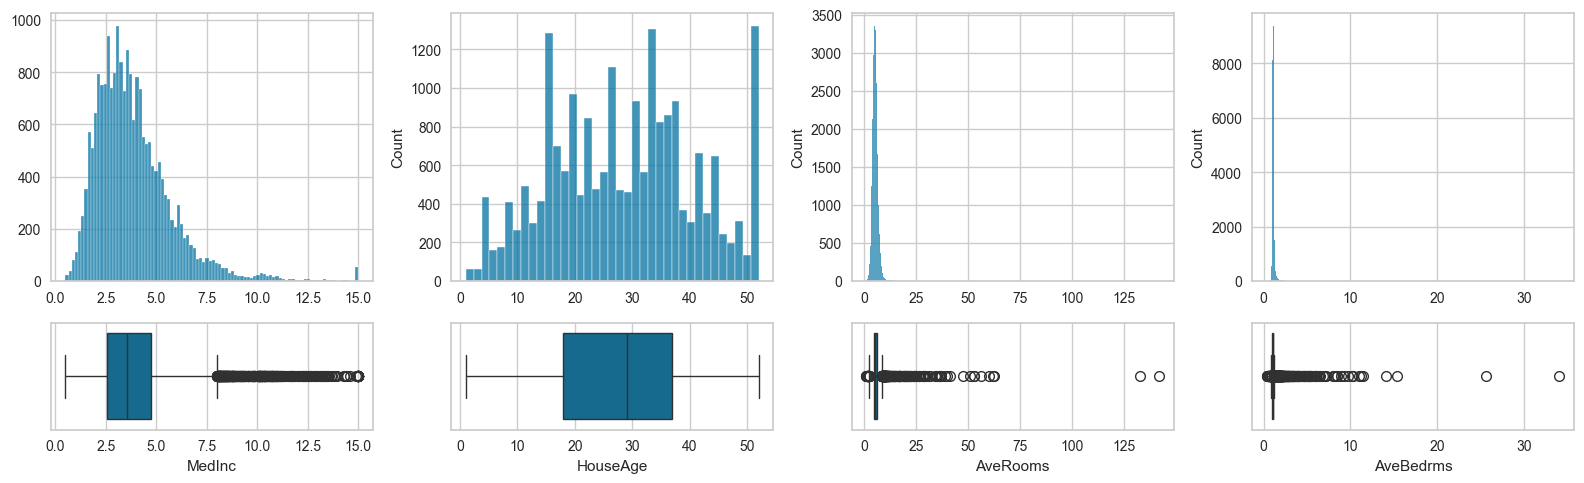

In [51]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="MedInc").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="MedInc")
sns.histplot(ax=axis[0, 1], data=df, x="HouseAge").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="HouseAge")
sns.histplot(ax=axis[0, 2], data=df, x="AveRooms").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="AveRooms")
sns.histplot(ax=axis[0, 3], data=df, x="AveBedrms").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="AveBedrms")
plt.tight_layout()
plt.show()

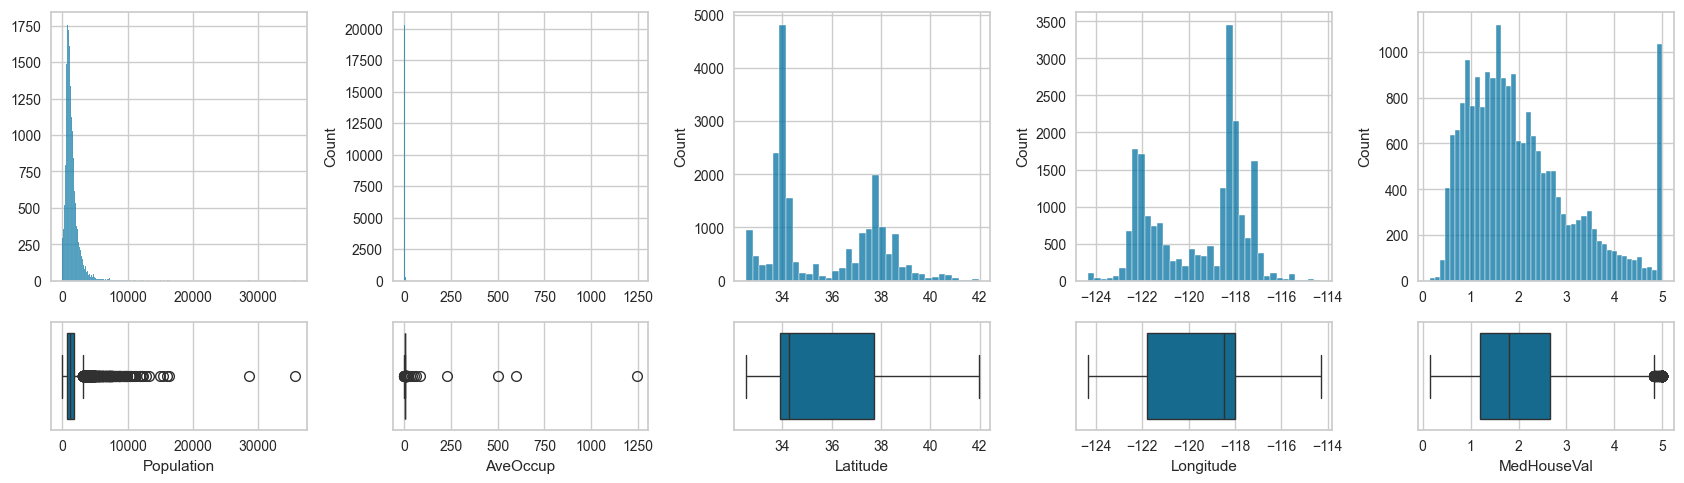

In [52]:
fig, axis = plt.subplots(2, 5, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="Population").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="Population")
sns.histplot(ax=axis[0, 1], data=df, x="AveOccup").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="AveOccup")
sns.histplot(ax=axis[0, 2], data=df, x="Latitude").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="Latitude")
sns.histplot(ax=axis[0, 3], data=df, x="Longitude").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="Longitude")
sns.histplot(ax=axis[0, 4], data=df, x="MedHouseVal").set(xlabel=None)
sns.boxplot(ax=axis[1, 4], data=df, x="MedHouseVal")

plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.
> - La variables siguen una distribución normalizada un poco sesgada hacia la izquierda

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

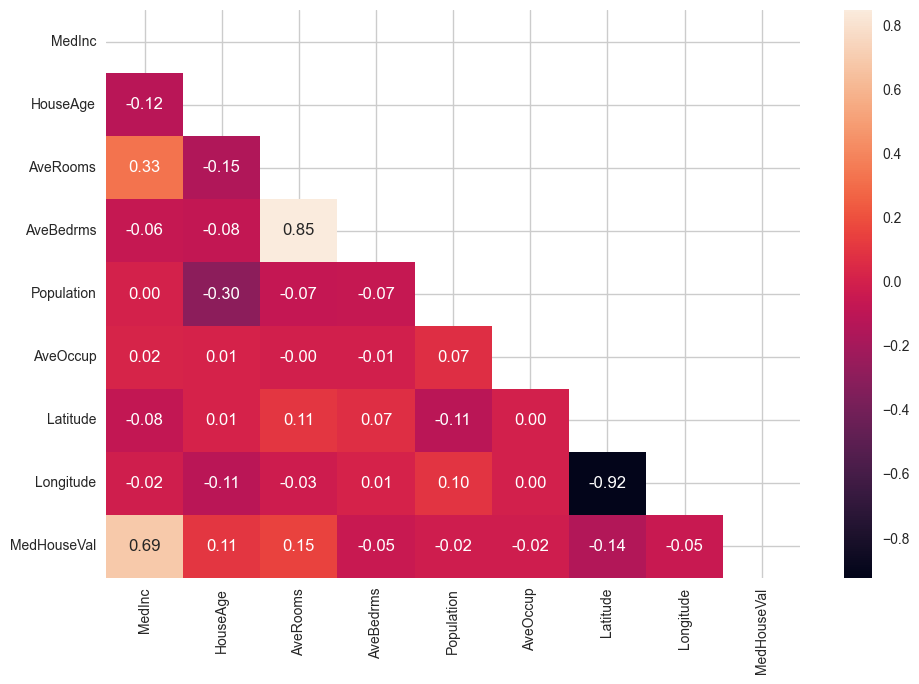

In [53]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [54]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Scaling & Encoding

### Scaling

#### Usamos el método RobustScaler porque es mejor para un modelo con valores atípicos, además es necesario escalar para hacer clustering con K-means

In [55]:
df_cluster = df[['Latitude', 'Longitude', 'MedInc']]

In [56]:
standard_scaler = StandardScaler() 
standard_features = standard_scaler.fit_transform(df_cluster)
df_scaled = pd.DataFrame(standard_features,
                         index=df_cluster.index,
                         columns=df_cluster.columns)
df_scaled

,Latitude,Longitude,MedInc
0,1.052548,-1.327835,2.344766
1,1.043185,-1.322844,2.332238
2,1.038503,-1.332827,1.782699
3,1.038503,-1.337818,0.932968
4,1.038503,-1.337818,-0.012881
...,...,...,...
20635,1.801647,-0.758826,-1.216128
20636,1.806329,-0.818722,-0.691593
20637,1.778237,-0.823713,-1.142593
20638,1.778237,-0.873626,-1.054583


## Clustering

In [57]:
k_model = KMeans(n_clusters = 6, n_init=10, random_state = 24)
df_scaled['cluster'] = k_model.fit_predict(df_scaled)
df_scaled

,Latitude,Longitude,MedInc,cluster
0,1.052548,-1.327835,2.344766,3
1,1.043185,-1.322844,2.332238,3
2,1.038503,-1.332827,1.782699,3
3,1.038503,-1.337818,0.932968,3
4,1.038503,-1.337818,-0.012881,2
...,...,...,...,...
20635,1.801647,-0.758826,-1.216128,2
20636,1.806329,-0.818722,-0.691593,2
20637,1.778237,-0.823713,-1.142593,2
20638,1.778237,-0.873626,-1.054583,2


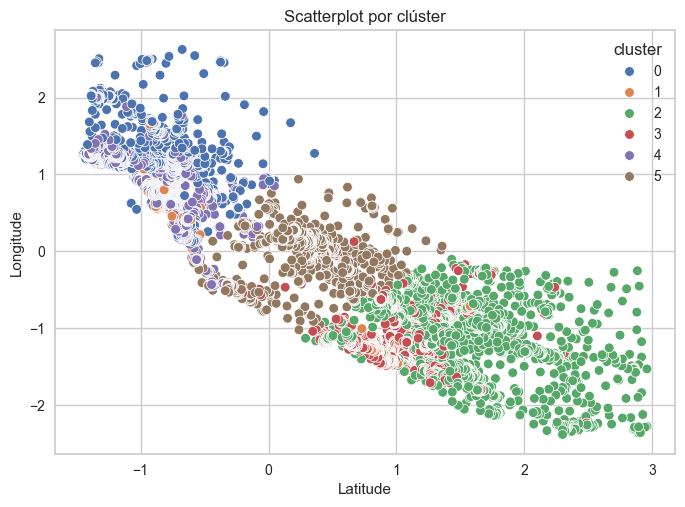

In [58]:
sns.scatterplot(data=df_scaled, x='Latitude', y='Longitude', hue='cluster', palette='deep')
plt.title('Scatterplot por clúster')
plt.show()

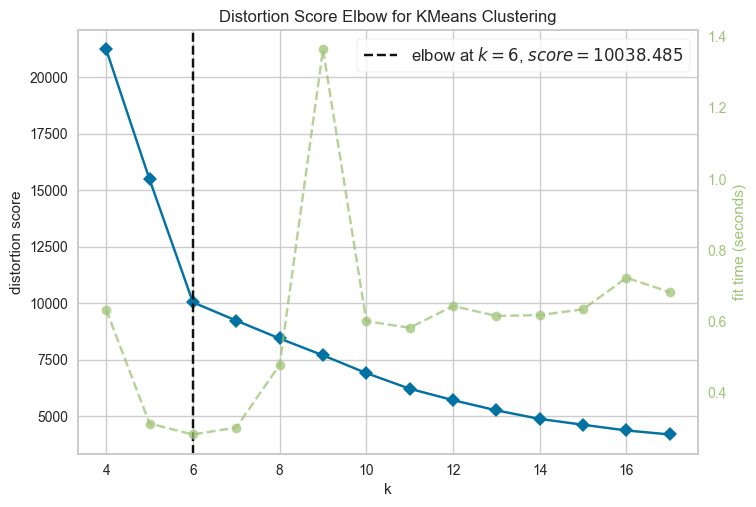

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [59]:
visualizer = KElbowVisualizer(k_model, k=(4,18))
visualizer.fit(df_scaled) 
visualizer.show()

In [60]:
# Definir el rango de número de clústeres para probar
k_values = range(2, 4)
# Inicializar listas para almacenar los valores de silhouette para cada número de clústeres
silhouette_scores = []
# Probar diferentes valores de k
for k in k_values:
    cluster_labels = KMeans(n_clusters=k, random_state=24).fit_predict(df_scaled)
    silhouette_scores.append(silhouette_score(df_scaled, cluster_labels))


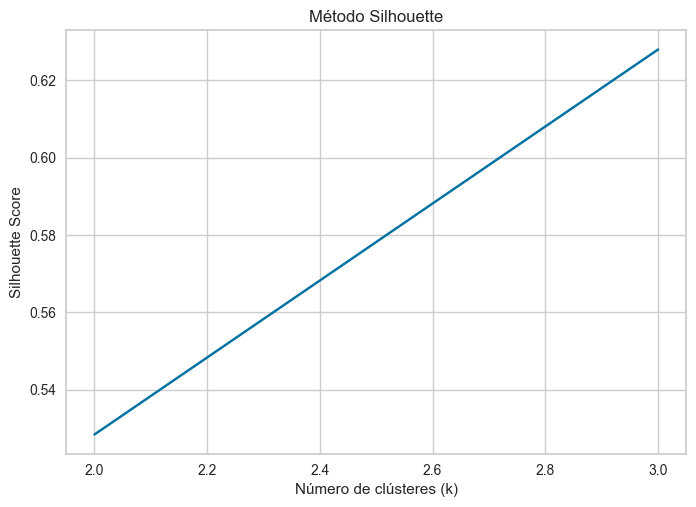

In [61]:
plt.plot(k_values, silhouette_scores)
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Silhouette Score')
plt.title('Método Silhouette')
plt.show()

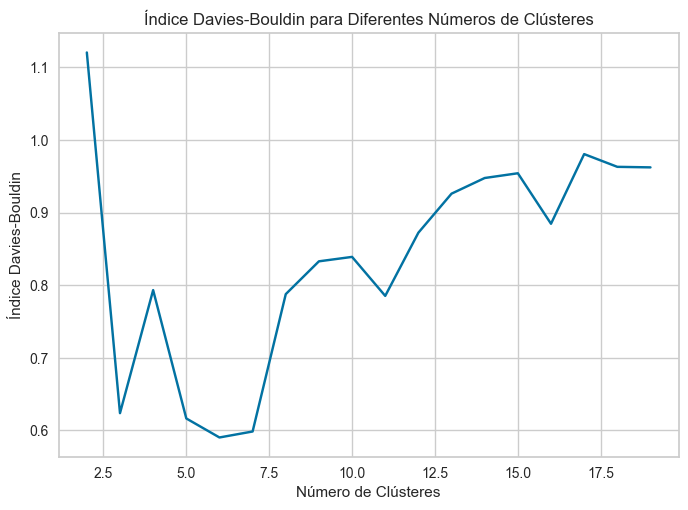

In [62]:
num_clusters = range(2, 20)
db_scores = []

# Probar diferentes valores de k
for k in num_clusters:
    cluster_labels = KMeans(n_clusters=k, random_state=18).fit_predict(df_scaled)
    db_scores.append(davies_bouldin_score(df_scaled, cluster_labels))

plt.plot(num_clusters, db_scores)
plt.title('Índice Davies-Bouldin para Diferentes Números de Clústeres')
plt.xlabel('Número de Clústeres')
plt.ylabel('Índice Davies-Bouldin')
plt.show()

In [63]:
cluster_labels

array([ 3,  3,  3, ..., 13, 13,  2], shape=(20640,), dtype=int32)

In [64]:
df_scaled.head()

,Latitude,Longitude,MedInc,cluster
0,1.052548,-1.327835,2.344766,3
1,1.043185,-1.322844,2.332238,3
2,1.038503,-1.332827,1.782699,3
3,1.038503,-1.337818,0.932968,3
4,1.038503,-1.337818,-0.012881,2


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Split de datos

In [66]:
X = df_scaled[['Latitude', 'Longitude', 'MedInc']]
y = df_scaled['cluster']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,Latitude,Longitude,MedInc
19464,0.963593,-0.698931,-0.212641
13265,-0.717197,0.958183,-0.739019
5829,-0.675060,0.633748,0.544027
5111,-0.782743,0.628757,0.100975
19761,2.096604,-1.297887,-1.105326
...,...,...,...
6500,-0.731243,0.763522,-0.794605
19857,0.336223,0.074722,-1.161280
14528,-1.269657,1.212740,-0.029830
899,0.893365,-1.198061,0.443647


In [68]:
X_train.to_csv("../data/processed/xtrain-k-means.csv", index=False)
X_test.to_csv("../data/processed/xtest-k-means.csv", index=False)
y_train.to_csv("../data/processed/ytrain-k-means.csv", index=False)
y_test.to_csv("../data/processed/ytest-k-means.csv", index=False)